# Benchmark: PXD014777 HeLa, Yeast and Ecoli dataset

In this notebook, the results of running multiple tests are visualized.
It is assumed that the corresponding multi test script has been run prior to the visualizations section in this notebook.

In [114]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objs as go
import numpy as np
import pickle
import os

import pipp
import pipp.utils

np.random.seed(0)

## Optional: Preparing MSMS sequence embeddings


If you want to use sequence embeddings for the MSMS data (prototypes), then run the following code to get the sequence of each prototype first. Afterwards run the script which computes the sequence embeddings for each prototype in `scripts/`.

In [3]:
PRETRAINED_MODEL_PATH = "../../checkpoints/checkpoint1.pth"
SPECIES_MSMS_PATH = "../../data/PXD014777/processed/species_ms2.csv"
HELA_MSMS_PATH = "../../data/PXD014777/processed/hela_ms2.csv"

In [4]:
df_msms_hela = pd.read_csv(HELA_MSMS_PATH, low_memory=False)
df_msms_species = pd.read_csv(SPECIES_MSMS_PATH, low_memory=False)

In [6]:
df_msms_all = pd.concat([df_msms_hela, df_msms_species], ignore_index=True)

In [7]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [8]:
prototype_sequences = model.get_prototype_sequences(df_msms_all)

In [9]:
dir = "../../outputs"
os.makedirs(dir, exist_ok=True)

filename = "prototype_sequences.pkl"
path = os.path.join(dir, filename)

with open(path, "wb") as f:
    pickle.dump(prototype_sequences, f)

## Visualizing the results

In [ ]:
def extract_by_confidence(
    df: pd.DataFrame,
    confidence_threshold: float,
) -> pd.DataFrame:
    fdrs_list = []
    for thresholds, fdrs in zip(df["stats_thresholds"], df["stats_fdr"]):
        idx = np.where(thresholds == confidence_threshold)[0]

        if len(idx) == 0:
            raise ValueError("Confidence threshold not computed!")

        fdr = fdrs[idx[0]]
        fdrs_list.append(fdr)

    result = df.copy()
    result["fdr"] = fdrs_list
    result.drop(columns=["stats_thresholds", "stats_fdr"], inplace=True)

    return result

In [103]:
RESULTS_DIR = "../../results"

files = os.listdir(RESULTS_DIR)

results = []
for file in files:
    if not file.endswith(".pkl"):
        continue

    path = os.path.join(RESULTS_DIR, file)

    with open(path, "rb") as f:
        result = pickle.load(f)

    result = pipp.utils.flat_dict(result)
    results.append(result)

df_all = pd.DataFrame(results)

In [105]:
confidence_threshold = 1
df = extract_by_confidence(df_all, confidence_threshold)

Let's first extract the HeLa MS2 entries from the HeLa MS1 data.

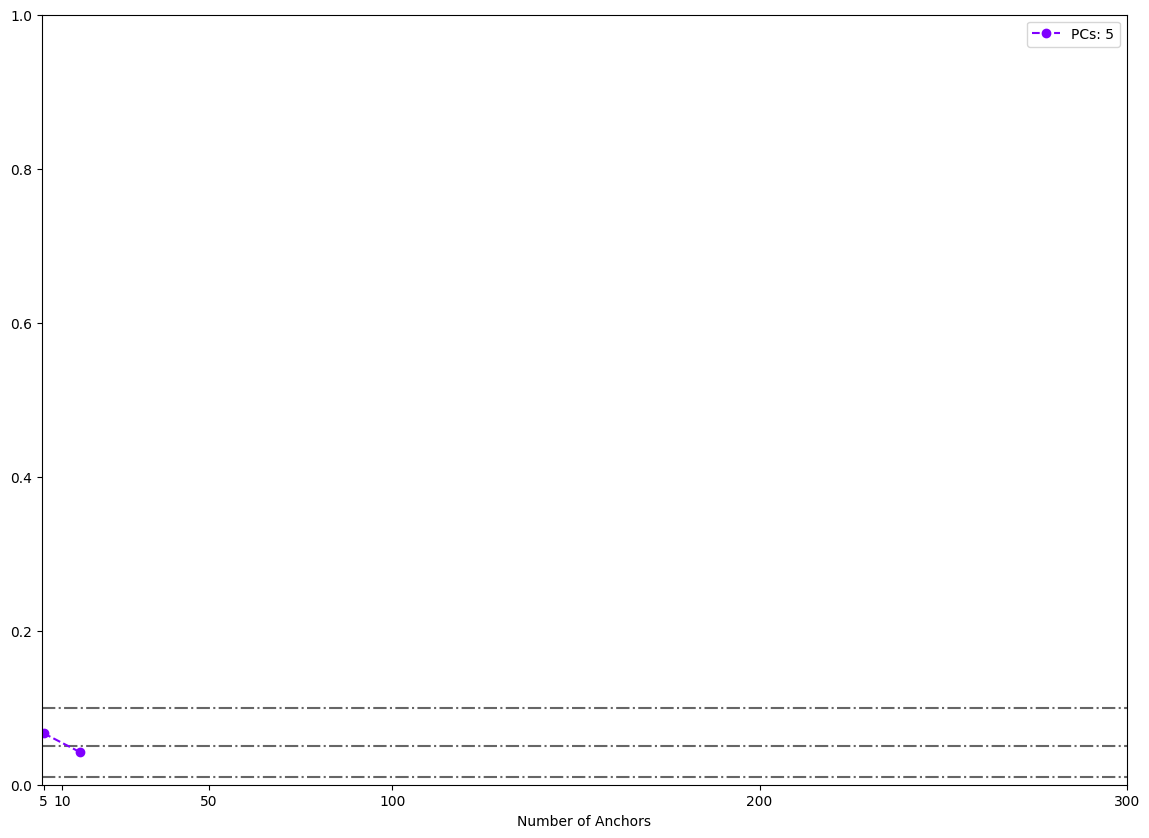

In [110]:
unique_n_pc = df["n_pcs"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_pc)))

plt.figure(figsize=(14, 10))
plt.axhline(y=0.01, color="black", linestyle="dashdot", alpha=0.6)
plt.axhline(y=0.05, color="black", linestyle="dashdot", alpha=0.6)
plt.axhline(y=0.1, color="black", linestyle="dashdot", alpha=0.6)

plt.ylim(0, 1)

for i, n_pcs in enumerate(unique_n_pc):
    subset_df = df[df["n_pcs"] == n_pcs]
    mean_values = subset_df.groupby("n_anchors")["fdr"].mean()
    plt.plot(
        mean_values.index,
        mean_values.values,
        marker="o",
        linestyle="--",
        label=f"PCs: {int(n_pcs)}" if n_pcs > 0 else "Without ESM",
        color=colors[i],
    )

plt.xlabel("Number of Anchors")
plt.xticks([5, 10, 50, 100, 200, 300])
plt.legend()

plt.show()

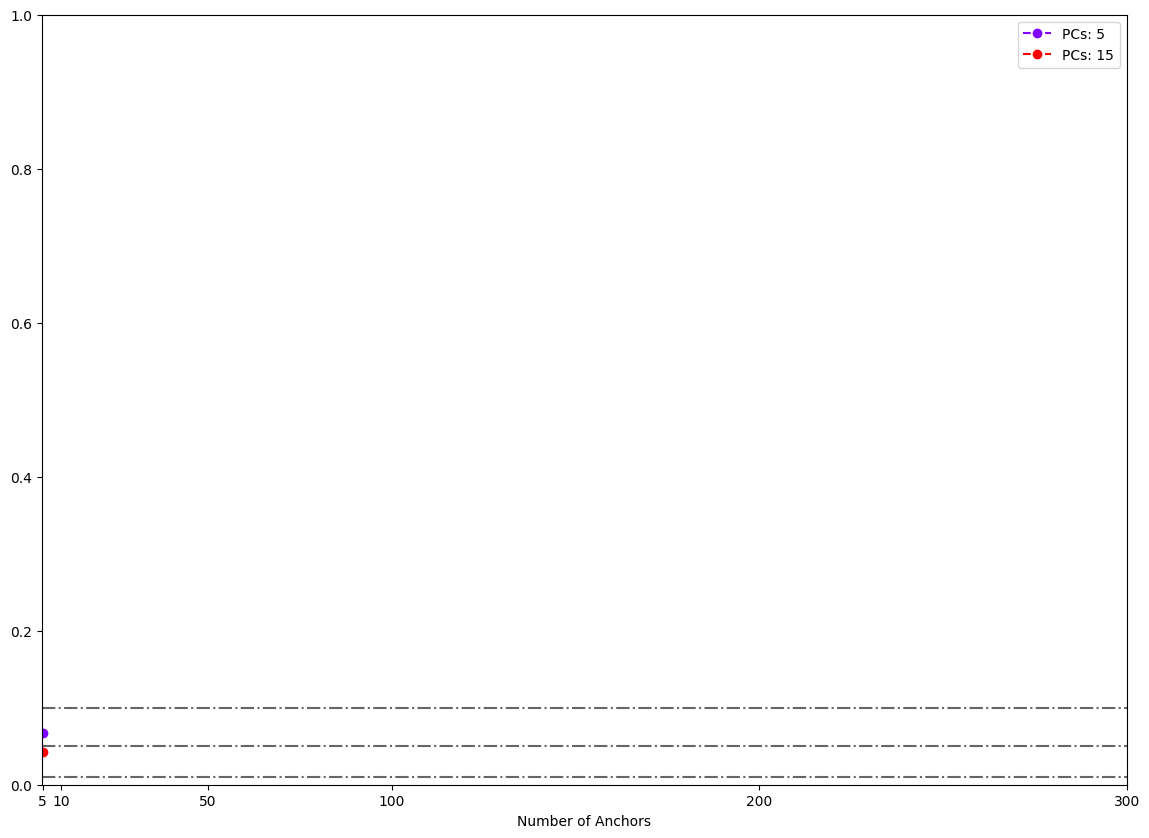

In [111]:
unique_groups = df["n_anchors"].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_groups)))

plt.figure(figsize=(14, 10))
plt.axhline(y=0.01, color="black", linestyle="dashdot", alpha=0.6)
plt.axhline(y=0.05, color="black", linestyle="dashdot", alpha=0.6)
plt.axhline(y=0.1, color="black", linestyle="dashdot", alpha=0.6)

plt.ylim(0, 1)

for i, group in enumerate(unique_groups):
    subset_df = df[df["n_anchors"] == group]
    mean_values = subset_df.groupby("n_pc")["fdr"].mean()
    plt.plot(
        mean_values.index,
        mean_values.values,
        marker="o",
        linestyle="--",
        label=f"PCs: {int(group)}" if group > 0 else "Without ESM",
        color=colors[i],
    )

plt.xlabel("Number of Anchors")
plt.xticks([5, 10, 50, 100, 200, 300])
plt.legend()

plt.show()

In [112]:
# Create a 3D scatter plot
fig = go.Figure(
    data=[go.Scatter3d(x=df["n_anchors"], y=df["n_pcs"], z=df["fdr"], mode="markers")]
)
fig.update_layout(
    scene=dict(
        aspectmode="cube",
        xaxis=dict(title="Number of Anchors"),
        yaxis=dict(title="Number of PCs"),
        zaxis=dict(title="FDR at Confidence Level 1"),
    ),
    title="3D Scatter Plot",
    width=800,
    height=800,
)
fig.show()

In [113]:
# Create 3D surface plot
df_agg = df.groupby(["n_anchors", "n_pcs"]).mean().reset_index()

# Reshape the DataFrame into a grid
x_vals = sorted(df_agg["n_anchor"].unique())
y_vals = sorted(df_agg["n_pc"].unique())
z_vals = df_agg.pivot(index="n_anchor", columns="n_pc", values="fdr").values

# Create the surface plot
fig = go.Figure(data=[go.Surface(z=z_vals, x=x_vals, y=y_vals)])

# Update layout with axis labels and title
fig.update_layout(
    scene=dict(
        xaxis_title="Number of Anchors",
        yaxis_title="Number of PCs",
        zaxis_title="FDR at Confidence Level 1",
    ),
    title="3D Surface Plot",
    width=800,
    height=800,
)

fig.show()